## 1. 探查 2015 - 2017 级专业填报与录取情况
### 1.1 取数

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/Users/juri/Happy_coding/art_school_with_low_graduation_rate/data/processed/art_school_reassign.db')

query = """
SELECT
		s.grad_major,
		s.enroll_year,
		COUNT(*)  AS class_size,
		COUNT(CASE WHEN is_reassign = True THEN 1 END) AS reassign_size,
		ROUND(COUNT(CASE WHEN is_reassign = True THEN 1 END) *100.0 / COUNT(*)  ,1) AS reassign_pct
FROM  dim_student s  JOIN fact_major_reassign m
		ON s.uid = m.uid
GROUP BY 1,2
"""

df_bar = pd.read_sql_query(query, conn)
conn.close()

df_bar['voluntary_size'] = df_bar['class_size'] - df_bar['reassign_size']
print(df_bar)


  grad_major enroll_year  class_size  reassign_size  reassign_pct  \
0    服装与服饰设计        2015          23             15          65.2   
1    服装与服饰设计        2016          29             19          65.5   
2    服装与服饰设计        2017          22              8          36.4   
3       环境设计        2015          39              4          10.3   
4       环境设计        2016          35              0           0.0   
5       环境设计        2017          34              0           0.0   
6     视觉传达设计        2015          36             11          30.6   
7     视觉传达设计        2016          36              5          13.9   
8     视觉传达设计        2017          34              0           0.0   

   voluntary_size  
0               8  
1              10  
2              14  
3              35  
4              35  
5              34  
6              25  
7              31  
8              34  


### 1.2 画图（堆叠柱状图）

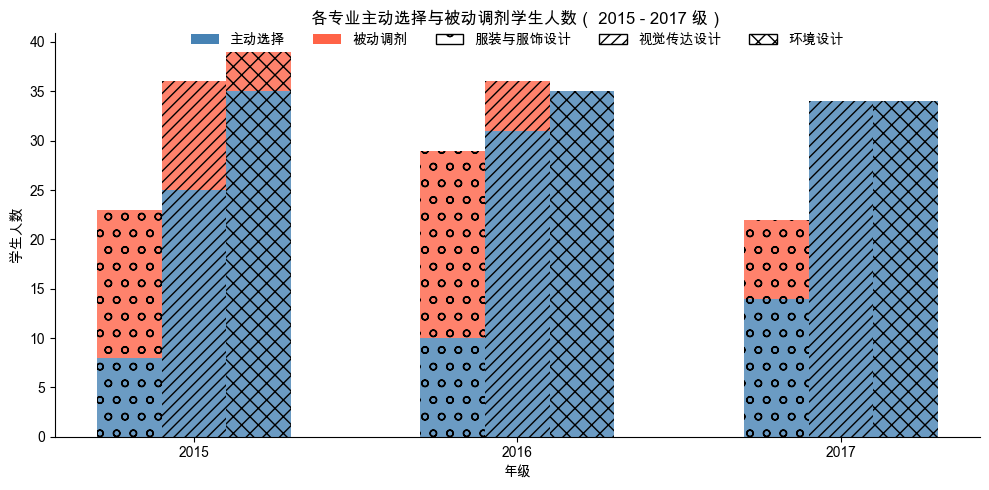

In [8]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rc('font', family='Arial Unicode MS')

majors = ['服装与服饰设计', '视觉传达设计', '环境设计']
years = ['2015', '2016', '2017']
hatch_patterns = ['o', '///', 'xx']  # 三个专业对应三种填充样式

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(years))  # [0, 1, 2]
n_majors = len(majors)
bar_width = 0.2

for i, (major, hatch) in enumerate(zip(majors, hatch_patterns)):
       df_major = df_bar[df_bar['grad_major'] == major].sort_values('enroll_year')

       voluntary = df_major['voluntary_size'].values
       reassign = df_major['reassign_size'].values

       offset = (i-1 ) * bar_width  # 让三个专业的柱子并排

       # 主动选择（蓝色，底部）
       ax.bar(x + offset, voluntary, bar_width,
       label=f'{major}-主动选择' if i == 0 else '',
       color='steelblue', hatch=hatch, alpha=0.8)

       # 被调剂（红色，堆叠在上面）
       ax.bar(x + offset, reassign, bar_width,
       bottom=voluntary,
       label=f'{major}-被调剂' if i == 0 else '',
       color='tomato', hatch=hatch, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel('年级')
ax.set_ylabel('学生人数')
ax.set_title('各专业主动选择与被动调剂学生人数（ 2015 - 2017 级）')

from matplotlib.patches import Patch
legend_elements = [
       Patch(facecolor='steelblue', label='主动选择'),
       Patch(facecolor='tomato', label='被动调剂'),
       Patch(facecolor='white', hatch='o', edgecolor='black', label='服装与服饰设计'),
       Patch(facecolor='white', hatch='///', edgecolor='black', label='视觉传达设计'),
       Patch(facecolor='white', hatch='xx', edgecolor='black', label='环境设计'),
]
ax.legend(handles=legend_elements, loc='upper right')

# 去除上方和右侧的边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例改为横排，放在标题下方
ax.legend(handles=legend_elements, 
       loc='upper center',
       bbox_to_anchor=(0.5, 1.03),    # 往标题方向移动
       ncol=5,                        # 5个图例项横排
       frameon=False)                 # 去除图例边框

plt.tight_layout()
plt.show()

## 2. 探查 2015 - 2017 级各专业学生第一学年 GPA 数据（主动选择 VS 被动调剂）

### 2.1 取数

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/Users/juri/Happy_coding/art_school_with_low_graduation_rate/data/processed/art_school_reassign.db')

query = """
SELECT
    s.enroll_year,
    s.grad_major,
    s.uid,
    g.gpa_score,
    m.is_reassign
FROM 
    dim_student s 
    INNER JOIN fact_gpa_records g ON s.uid = g.uid 
    INNER JOIN fact_major_reassign m ON g.uid = m.uid
WHERE 
    g.academic_period = '第一学年'
"""

df_y1_gpa = pd.read_sql_query(query, conn)
conn.close()

print(df_y1_gpa.shape)
print(df_y1_gpa.head())
print(df_y1_gpa['is_reassign'].value_counts())

(288, 5)
  enroll_year grad_major                                                uid  \
0        2015    服装与服饰设计  288d190be65dad4cf6da241b72528db1ee9c2e9118d636...   
1        2015    服装与服饰设计  f6d37c8a9819c2e3746e6772c1232b0773841d7131e3e1...   
2        2015    服装与服饰设计  6fe6b6fbc1e82f04c1e28bc9f1d524eb04aada5f8d279e...   
3        2015     视觉传达设计  bbbed2a516d1429e1edd2695b4621e89ed66036d3fe1e4...   
4        2015       环境设计  8d7275f799f8ed11987c27da9a62de698593ace51c7014...   

   gpa_score  is_reassign  
0      2.280            1  
1      2.395            1  
2      2.750            1  
3      2.240            1  
4      2.805            1  
is_reassign
0    226
1     62
Name: count, dtype: int64


### 2.2 画图（箱线图）

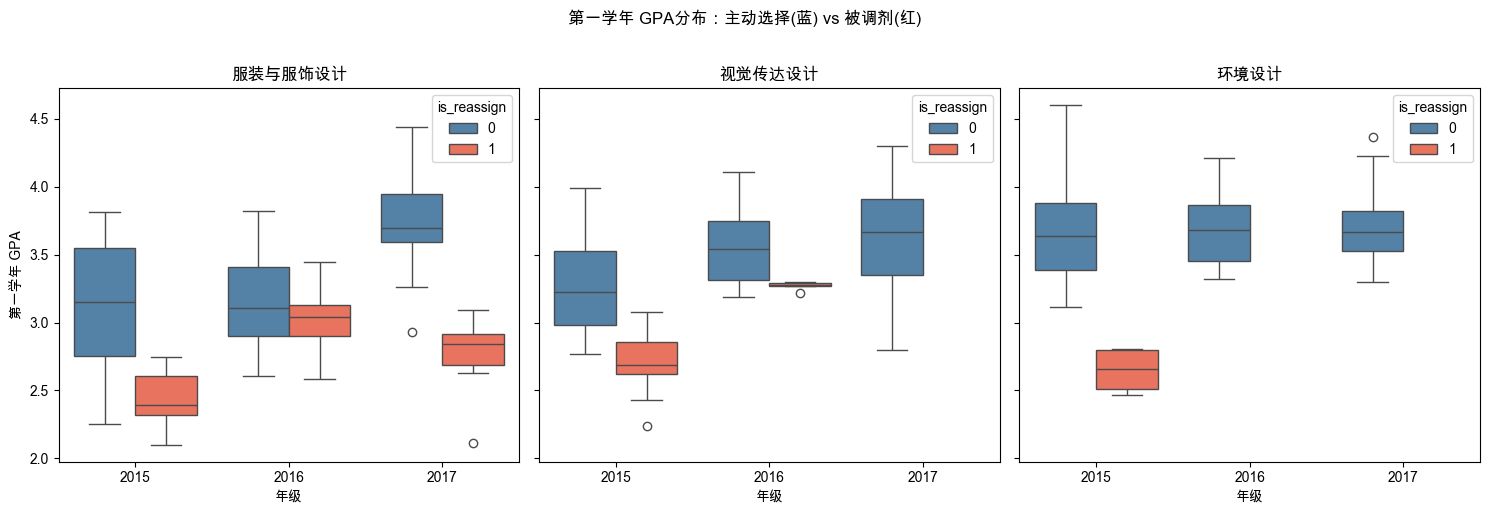

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rc('font', family='Arial Unicode MS')  

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

majors = ['服装与服饰设计', '视觉传达设计', '环境设计']

for ax, major in zip(axes, majors):
    data = df_y1_gpa[df_y1_gpa['grad_major'] == major]
    sns.boxplot(
        data=data,
        x='enroll_year',
        y='gpa_score',
        hue='is_reassign',
        palette={0: 'steelblue', 1: 'tomato'},
        ax=ax
    )
    ax.set_title(major)
    ax.set_xlabel('年级')
    ax.set_ylabel('第一学年 GPA')

plt.suptitle('第一学年 GPA分布：主动选择(蓝) vs 被调剂(红)', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 使用 Mann-Whitney U 检验来量化 [被调剂学生] 和 [主动选择学生] 的第一学年 GPA 分布

  原假设（H₀）： 被调剂学生和主动选择学生的大一学年 GPA 分布没有显著差异 <br>
备择假设（H₁）： 两组的GPA分布有显著差异

**判断标准：p < 0.05 则拒绝原假设，认为差异显著。**

#### 2.3.1 服装与服饰设计专业

In [3]:
from scipy import stats

# 筛选服装专业
df_fashion = df_y1_gpa[df_y1_gpa['grad_major'] == '服装与服饰设计']

# 分成两组
group_reassigned_f = df_fashion[df_fashion['is_reassign'] == 1]['gpa_score']
group_voluntary_f = df_fashion[df_fashion['is_reassign'] == 0]['gpa_score']

print(f"被调剂人数：{len(group_reassigned_f)}")
print(f"主动选择人数：{len(group_voluntary_f)}")
print(f"被调剂中位数：{group_reassigned_f.median():.3f}")
print(f"主动选择中位数：{group_voluntary_f.median():.3f}")

stat, p = stats.mannwhitneyu(group_reassigned_f, group_voluntary_f, alternative='two-sided')
print(f"\nMann-Whitney U 统计量：{stat:.3f}")
print(f"p 值：{p:.4f}")
print(f"结论：{'服装专业学生第一学年 GPA 分布差异显著 ✅' if p < 0.05 else '服装专业学生第一学年 GPA 分布差异不显著 ❌'}")

被调剂人数：42
主动选择人数：32
被调剂中位数：2.780
主动选择中位数：3.447

Mann-Whitney U 统计量：211.000
p 值：0.0000
结论：服装专业学生第一学年 GPA 分布差异显著 ✅


#### 2.3.2 视觉传达设计专业

In [4]:
from scipy import stats

# 筛选视传专业
df_visual = df_y1_gpa[df_y1_gpa['grad_major'] == '视觉传达设计']

# 分成两组
group_reassigned_v = df_visual[df_visual['is_reassign'] == 1]['gpa_score']
group_voluntary_v = df_visual[df_visual['is_reassign'] == 0]['gpa_score']

print(f"被调剂人数：{len(group_reassigned_v)}")
print(f"主动选择人数：{len(group_voluntary_v)}")
print(f"被调剂中位数：{group_reassigned_v.median():.3f}")
print(f"主动选择中位数：{group_voluntary_v.median():.3f}")

stat, p = stats.mannwhitneyu(group_reassigned_v, group_voluntary_v, alternative='two-sided')
print(f"\nMann-Whitney U 统计量：{stat:.3f}")
print(f"p 值：{p:.4f}")
print(f"结论：{'视传专业学生第一学年 GPA 分布差异显著 ✅' if p < 0.05 else '视传专业学生第一学年 GPA 分布差异不显著 ❌'}")

被调剂人数：16
主动选择人数：90
被调剂中位数：2.860
主动选择中位数：3.527

Mann-Whitney U 统计量：160.500
p 值：0.0000
结论：视传专业学生第一学年 GPA 分布差异显著 ✅


#### 2.3.3 环境设计专业

In [5]:
from scipy import stats

# 筛选环艺专业
df_environ = df_y1_gpa[df_y1_gpa['grad_major'] == '环境设计']

# 分成两组
group_reassigned_e = df_environ[df_environ['is_reassign'] == 1]['gpa_score']
group_voluntary_e = df_environ[df_environ['is_reassign'] == 0]['gpa_score']

print(f"被调剂人数：{len(group_reassigned_e)}")
print(f"主动选择人数：{len(group_voluntary_e)}")
print(f"被调剂中位数：{group_reassigned_e.median():.3f}")
print(f"主动选择中位数：{group_voluntary_e.median():.3f}")

stat, p = stats.mannwhitneyu(group_reassigned_e, group_voluntary_e, alternative='two-sided')
print(f"\nMann-Whitney U 统计量：{stat:.3f}")
print(f"p 值：{p:.4f}")
print(f"结论：{'环境设计专业学生第一学年 GPA 分布差异显著 ✅' if p < 0.05 else '环境设计专业学生第一学年 GPA 分布差异不显著 ❌'}")

被调剂人数：4
主动选择人数：104
被调剂中位数：2.660
主动选择中位数：3.665

Mann-Whitney U 统计量：0.000
p 值：0.0007
结论：环境设计专业学生第一学年 GPA 分布差异显著 ✅


## 3. 探查 2014 - 2017 级服装专业学生第一学年 GPA 分布变化、毕业率变化的规律 （ 2014级无分流组 VS 2015-2017级主动选择组 VS 2015-2017级被动调剂组 ）

### 3.1 三组服装专业学生的 第一学年 GPA 中位数

In [11]:
query = """
SELECT 
    CASE 
        WHEN s.enroll_year = '2014' THEN '2014'
        ELSE '2015-2017'
    END AS year_group,		
    CASE                                                 
        WHEN m.is_reassign = 0 THEN '主动选择'
        WHEN m.is_reassign = 1 THEN '被动分流'
        ELSE '无分流'
    END AS reassign_group,
    g.gpa_score
FROM dim_student AS s 
    LEFT JOIN fact_major_reassign AS m ON s.uid = m.uid 
    INNER JOIN fact_gpa_records AS g ON s.uid = g.uid
WHERE 
    s.grad_major = '服装与服饰设计' AND g.academic_period = '第一学年'
"""

conn = sqlite3.connect('/Users/juri/Happy_coding/art_school_with_low_graduation_rate/data/processed/art_school_reassign.db')
df_fashion_gpa = pd.read_sql_query(query, conn)
conn.close()

print(df_fashion_gpa.groupby(['year_group','reassign_group'])['gpa_score'].median())

year_group  reassign_group
2014        无分流               3.7200
2015-2017   主动选择              3.4475
            被动分流              2.7800
Name: gpa_score, dtype: float64


### 3.2 三组服装专业学生在校就读四年后毕业的比例

In [23]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/Users/juri/Happy_coding/art_school_with_low_graduation_rate/data/processed/art_school_reassign.db')

query = """
SELECT 
        CASE 
				WHEN s.enroll_year = "2014" THEN "2014"
				ELSE "2015-2017"
		END AS year_group,		
		CASE                                                 
				WHEN m. is_reassign = 0 THEN "主动选择"
				WHEN m. is_reassign = 1 THEN "被动分流"
				ELSE "无分流"
		END AS reassign_group,	
		s.grad_status,
		COUNT(*)
FROM dim_student s LEFT JOIN fact_major_reassign m ON s.uid = m.uid 
WHERE  s.grad_major = "服装与服饰设计"
GROUP BY 1,2,3
"""

df_grad = pd.read_sql_query(query, conn)
conn.close()

print(df_grad)

# 计算每组学生的四年正常毕业率(百分比)
print(
    round(
        df_grad.groupby('reassign_group').apply(
            lambda g: g[g['grad_status']=='四年正常']['COUNT(*)'].sum()/g['COUNT(*)'].sum(),
            include_groups=False
        ),4
    )*100
)

  year_group reassign_group grad_status  COUNT(*)
0       2014            无分流        四年正常        23
1  2015-2017           主动选择        五年异常         1
2  2015-2017           主动选择        六年异常         1
3  2015-2017           主动选择        四年正常        29
4  2015-2017           主动选择         未毕业         1
5  2015-2017           被动分流        五年异常         4
6  2015-2017           被动分流        六年异常         3
7  2015-2017           被动分流        四年正常        34
8  2015-2017           被动分流         未毕业         1
reassign_group
主动选择     90.62
无分流     100.00
被动分流     80.95
dtype: float64
